In [ ]:
import numpy as np
import pandas as pd 
from pathlib import Path
from multiprocessing import Pool

import matplotlib.pyplot as plt
%matplotlib widget

import seaborn as sns

import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.metrics import ConfusionMatrixDisplay, f1_score, balanced_accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from scipy.stats import gaussian_kde, linregress, pearsonr

from tqdm.auto import tqdm
tqdm.pandas()

THRESHOLD = 0.226

In [2]:
# Load predictions

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')

bm_pred_path = output_path / '38_mm4_transductif_reg-2025-12-17_15-41' / 'predictions-biomass.csv'
bm_predictions = pd.read_csv(bm_pred_path, index_col='survey_id')

predictions_sr = (predictions > THRESHOLD).sum(axis=1)
predictions_prev = (predictions > THRESHOLD).sum(axis=0)

In [3]:
# Load targets

input_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv') # _split.csv')
fulldf = pd.read_csv(input_path, index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})
species = predictions.columns
targets = fulldf.loc[fulldf['subset'] == 'test', species]

# Test dataset summary
targets_sr = (targets > 0).sum(axis=1)
targets_pres = (targets > 0).astype(int)
targets_prev = (targets > 0).sum(axis=0)
targets_bm = targets.sum(axis=1)
#species_bm = fulldf.loc[fulldf['subset'] == 'test',fulldf.columns[-1718:-1]].sum(axis=0)

## Dataset stats

In [13]:
allspeciesnames = fulldf.columns[-1797:-1]
fulltargets = fulldf[allspeciesnames]
allspecies_prev = (fulltargets > 0).sum(axis=0) / fulltargets.shape[0]
allspecies_bm = fulltargets.sum(axis=0)
 

In [71]:
allspecies_prev.describe()

count    1796.000000
mean        0.010680
std         0.028970
min         0.000036
25%         0.000182
50%         0.001294
75%         0.008055
max         0.478041
dtype: float64

## Outputs visualization

#### Species richness

In [14]:
print(linregress(targets_sr, predictions_sr))

LinregressResult(slope=0.9006319539203141, intercept=2.721095854488034, rvalue=0.7879205214294985, pvalue=0.0, stderr=0.0100032680049999, intercept_stderr=0.2774968012985377)


In [16]:
fig = px.scatter(
    x=np.log(1+targets_sr), y=np.log(1+predictions_sr),
    marginal_y='violin', marginal_x='violin'
)

fig.update_layout(width=800, height=800)
fig.show()

[Text(0.5, 0, 'Ground truth species richness (logged)'),
 Text(0, 0.5, 'Predicted species richness (logged)')]

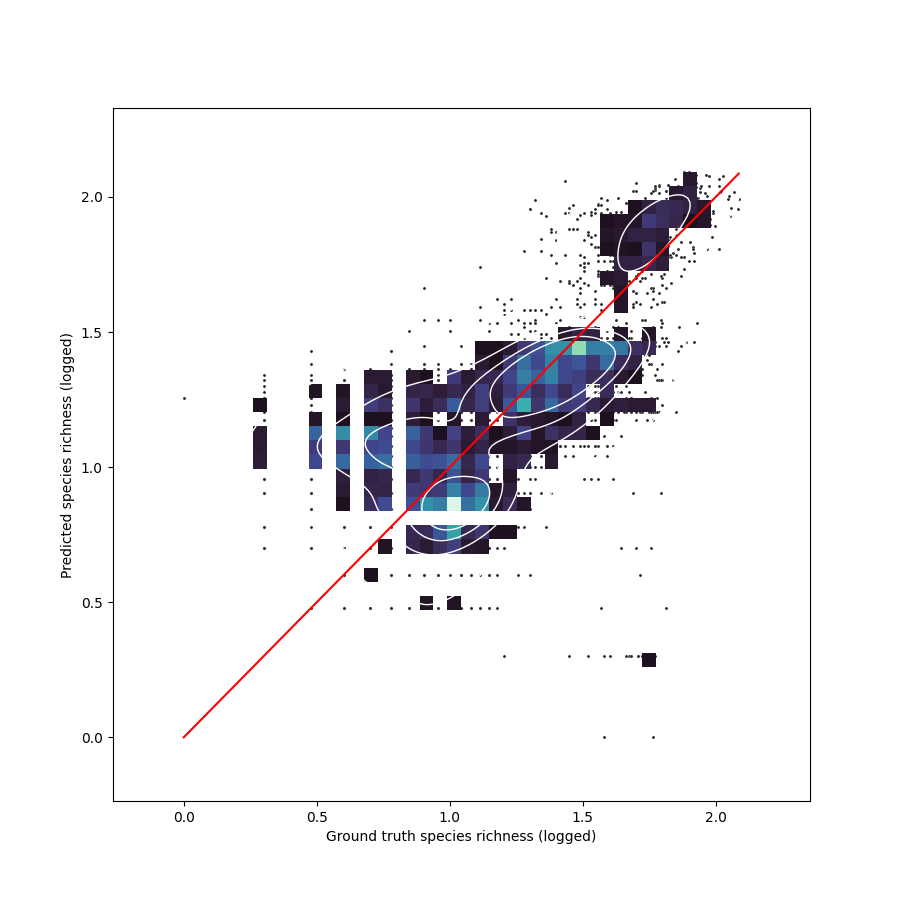

In [17]:
x, y = np.log10(1+targets_sr), np.log10(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='Ground truth species richness (logged)', ylabel='Predicted species richness (logged)')

#### Total biomass

In [4]:
pred_path = output_path / '38_mm4_transductif_reg-2025-12-17_15-41' / 'predictions-biomass.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')
pred_biomass = np.exp(predictions) - 1
total_bm_pred = pred_biomass.sum(axis=1)

In [ ]:
print(linregress(targets_bm, total_bm_pred))

LinregressResult(slope=0.013136253010742073, intercept=6.124915333338682, rvalue=0.6213009752218444, pvalue=0.0, stderr=0.00023545174932439078, intercept_stderr=0.29795118322791575)


In [ ]:
x, y = np.log10(1+targets_sr), np.log10(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='Ground truth species richness (logged)', ylabel='Predicted species richness (logged)')

#### Confusion matrix

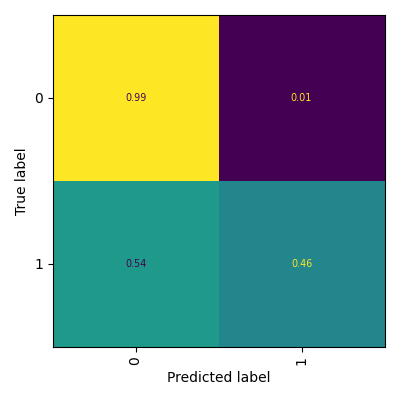

In [8]:
cm = confusion_matrix(targets_pres.to_numpy().flatten(), (predictions>THRESHOLD).to_numpy().flatten(), labels=(0,1), normalize = 'true')
cm = cm.round(2)

fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=(0,1))
disp.plot(xticks_rotation = 'vertical', colorbar = False, text_kw={'fontsize': 'x-small'},ax=ax)
plt.tight_layout()
plt.show()
#plt.savefig(pred_path.parent / 'confusion_matrix.png')


#### F1 by site

In [4]:
# F1 by site

f1scores = []
test_df = fulldf[fulldf['subset'] == 'test']

for site in test_df['site_code'].unique():
    surveys = test_df[test_df['site_code'] == site].index
    lat, lon = test_df.loc[surveys[0], 'latitude'], test_df.loc[surveys[0], 'longitude']
    preds = (predictions > THRESHOLD).astype(float).loc[surveys].to_numpy().flatten()
    targets = (test_df != 0).astype(float).loc[surveys, predictions.columns].to_numpy().flatten()
    f1 = f1_score(targets, preds)
    f1scores.append({'site':site, 'f1':f1, 'lat':lat, 'lon':lon})

pd.DataFrame(f1scores).to_csv(pred_path.parent / 'f1_by_site_new.csv')


In [6]:
pd.DataFrame(f1scores).describe()

,f1,lat,lon
count,412.000000,412.000000,412.000000
mean,0.416725,-29.308932,142.045558
std,0.145608,9.823767,12.718351
min,0.000000,-41.150000,113.340000
25%,0.337355,-38.180000,144.310000
50%,0.449022,-32.020000,146.115000
75%,0.516129,-20.800000,149.262500
max,0.747664,-10.500000,153.630000


#### Prevalence against F1

In [ ]:
df = pd.concat([f1, allspecies_prev.loc[f1.index].rename('prev'), allspecies_bm.loc[f1.index].rename('bm')], axis=1)

df['logprev'] = np.log10(1+df['prev'])
fig = px.scatter(df,
                 x='logprev',
                 y='f1',
                 size='bm',
                 template='simple_white',
                 hover_name=list(df.index),
                 width=1200,
                 height=800)

fig.show()

## Embeddings

#### Embedding (clustering)

In [4]:
### Export embeddings

pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
td_emb = np.load(pred_path.parent / 'embedding.npy')
td_emb_tv = np.load(pred_path.parent / 'embedding_trainval.npy')

test_df = fulldf[fulldf['subset'] == 'test']
tv_df = fulldf[fulldf['subset'].isin(['train','val'])]

emb_df = pd.DataFrame(td_emb, index=test_df.index, columns = range(td_emb.shape[1]))
emb_df_tv = pd.DataFrame(td_emb_tv, index=tv_df.index, columns= range(td_emb_tv.shape[1]))

embeddings = pd.concat([emb_df, emb_df_tv], axis=0).to_csv(pred_path.parent / 'embeddings_all.csv')

In [5]:
pred_path = output_path / '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31' / 'predictions-probs.csv'
emb = np.load(pred_path.parent / 'embedding.npy')

pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
td_emb = np.load(pred_path.parent / 'embedding.npy')

In [6]:
test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=3)
pca.fit(emb)
pca_emb = pca.transform(emb)

td_pca = PCA(n_components=3)
td_pca.fit(td_emb)
td_pca_emb = td_pca.transform(td_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2', 'pc3'], index = test_df.index)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=['pc1', 'pc2', 'pc3'], index = test_df.index)

In [7]:
n_clusters = 9

clustering = AgglomerativeClustering(n_clusters=n_clusters)
cluster_labels = clustering.fit_predict(pca_pd[['pc1', 'pc2', 'pc3']])
pca_pd['cluster_label'] = cluster_labels

td_clustering = AgglomerativeClustering(n_clusters=n_clusters)
td_cluster_labels = td_clustering.fit_predict(td_pca_pd[['pc1', 'pc2', 'pc3']])
td_pca_pd['cluster_label'] = td_cluster_labels

In [8]:
#fig = px.scatter_3d(pca_pd, x='pc1', y='pc2', z='pc3', color='cluster_label', height = 600, width = 800, color_continuous_scale=px.colors.sequential.Turbo)

fig = make_subplots(rows=1, cols=2,specs=[[{'type': 'surface'}, {'type': 'surface'}]])

fig.add_trace(
    go.Scatter3d(x=pca_pd['pc1'], y=pca_pd['pc2'], z=pca_pd['pc3'], mode='markers',
                 marker=dict(color=pca_pd['cluster_label'], colorscale=px.colors.sequential.Turbo)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(x=td_pca_pd['pc1'], y=td_pca_pd['pc2'], z=td_pca_pd['pc3'], mode='markers',
                 marker=dict(color=td_pca_pd['cluster_label'], colorscale=px.colors.sequential.Turbo)),
    row=1, col=2
)

fig.update_layout(height=800, width=1400)
fig.show()

# fig.update_scenes(xaxis_title_font_color="blue",
#                   xaxis_tickfont_color="blue",
#                   yaxis_title_font_color="red",
#                   yaxis_tickfont_color="red",  
#                   zaxis_title_font_color="green",
#                   zaxis_tickfont_color="green",)


In [20]:
to_export = pd.concat([pca_pd, test_df[['site_code', 'latitude', 'longitude', 'survey_date']]], axis=1)
to_export.to_csv(pred_path.parent / 'pca.csv')

#### Embeddings (vs colors)

In [20]:
pred_path = output_path / '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31' / 'predictions-probs.csv'
emb = np.load(pred_path.parent / 'embedding.npy')

pred_path = output_path / '37_mm4_transductif-2025-12-02_12-47' / 'predictions-probs.csv'
td_emb = np.load(pred_path.parent / 'embedding.npy')

env = pd.read_csv('/data/data/malpolon/xgb/X_compound_values_mm.csv', index_col='survey_id', usecols = list(range(20)) + [59])
env.columns = ["fsle", "fsle-orientation", "bathymetry", "chlorophyll", "sst", "salinity", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "protection-level", "distance-to-port", "population-density-log", "gravity", "dhw_max"]

ind = pd.read_csv('/data/data/RLS/eco_indicators.csv', index_col='survey_id')

In [14]:
test_df = fulldf[fulldf['subset'] == 'test']

pca = PCA(n_components=2)
pca.fit(emb)
pca_emb = pca.transform(emb)

td_pca = PCA(n_components=2)
td_pca.fit(td_emb)
td_pca_emb = td_pca.transform(td_emb)

pca_pd = pd.DataFrame(pca_emb, columns=['pc1', 'pc2'], index = test_df.index)
td_pca_pd = pd.DataFrame(td_pca_emb, columns=['pc1', 'pc2'], index = test_df.index)

In [ ]:
# Plot vs predictors

USE_CASE = 'TRANSDUCTIVE' ## or INDUCTIVE

if USE_CASE == 'TRANSDUCTIVE':
    data = td_pca_pd
else:
    data = pca_pd

fig = make_subplots(rows=4, cols=5, subplot_titles=env.columns,
                    horizontal_spacing = 0.02, vertical_spacing=0.04)

for i in range(len(env.columns)):
    var = env.columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=env.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 5, col=1 + i % 5
    )

fig.update_layout(height=1200, width=1500, showlegend=False)
fig.show()

In [28]:
# Plot vs indicators

USE_CASE = 'TRANSDUCTIVE' ## or INDUCTIVE

if USE_CASE == 'TRANSDUCTIVE':
    data = td_pca_pd
else:
    data = pca_pd

fig = make_subplots(rows=2, cols=5, subplot_titles=ind.columns,
                    horizontal_spacing = 0.02, vertical_spacing=0.1)

for i in range(len(ind.columns)):
    var = ind.loc[data.index].columns[i]
    fig.add_trace(
        go.Scatter( x=data['pc1'], y=data['pc2'], mode='markers',
                    marker=dict(color=ind.loc[data.index, var], colorscale='Spectral')),
        row= 1 + i // 5, col=1 + i % 5
    )

fig.update_layout(height=700, width=1500, showlegend=False)
fig.show()

## Interpretability

In [ ]:
best_species = pd.read_csv(pred_path.parent / 'best_species.csv', index_col = 0)
species = list(best_species.index)
ig_path = pred_path.parent / 'integrated_gradients'

labels = ["fsle", "fsle-orientation", "bathymetry_aus", "chlorophyll", "sst", "salinity3d", "ph", "surface-current-u",
"surface-current-v", "wind-u", "wind-v", "wave-height", "oxygen", "mixed-layer-thickness",
"nitrate", "prot_level", "distance-to-port", "pop-density-log", "gravity"]

#### Per variable density

In [ ]:
colors = plotly.colors.qualitative.Light24

def produce_charts(speci):

    presences = []
    absences = []
    for survey_id in list(targets.index):

        ig = np.load(ig_path / speci / f"ig_{survey_id}.npy")

        abs_ig = np.abs(ig).squeeze()
        averages = abs_ig.mean(axis=(1,2))

        if fulldf.loc[survey_id, s] > 0:
            presences.append(averages)
        else:
            absences.append(averages)

    
    presences = np.vstack(presences)
    absences = np.vstack(absences)

    p = pd.DataFrame(presences)
    a = pd.DataFrame(absences)
    a.columns = labels
    p.columns = labels

    fig = make_subplots(rows=2, cols=1, subplot_titles=("Presence", "Absence"))

    # Plot density for each column
    for i in range(len(a.columns)):
        column = a[s].columns[i]

        density = gaussian_kde(p[column])
        xs = np.linspace(p[column].min(), p[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=1, col=1)

        density = gaussian_kde(a[column])
        xs = np.linspace(a[column].min(), a[column].max(), 200)
        ys = density(xs)
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=column, line = dict(color=colors[i])), row=2, col=1)

    # Update layout
    fig.update_layout(title=speci,
                    xaxis_title='Value',
                    yaxis_title='Density',
                    template='plotly_white',
                    height = 800)

    # Show plot
    fig.update_yaxes(range=[0, 600]) 
    fig.update_xaxes(range=[0, 0.03]) 
    fig.write_image(pred_path.parent / "ig_densities" / f"{s}.png")

In [ ]:
with Pool(processes=18) as pool:
        results = pool.map(produce_charts, species)

#### Summary chart

In [ ]:
series_dict = {}

for i in range(len(species)):
    s = species[i]
    p = Path(output_path / ig_name / "ig_stats" / f"{s}_pres.csv")
    if p.exists():
        df = pd.read_csv(p, index_col = 0)
        series_dict[s] = df['50%']

df = pd.concat(series_dict, axis = 1).T
df.sort_values(ascending=False, by = 'bathymetry_aus', inplace = True)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.T, ax = ax, cbar=False, cmap='YlOrRd')
plt.tight_layout()

## Compare checkpoints

#### FP / FN

In [45]:
checkpoints = {'9_env_pa-2025-02-04_16-46-preds' : 'Environment17',
               '10_sat_pa-2025-02-05_17-32-preds' : 'Satellite',
               '11_satenv_pa-2025-02-06_11-50-preds' : 'Environment + Satellite',
               '9_env_pa-2025-03-11_10-31-preds' : 'Environment15',
               '13_hum_pa-2025-03-11_10-29-preds' : 'Human activities',
               '15_humenv_cat_pa-2025-03-11_10-32-preds' : 'Environment + Human activities<br><b>monomodal</b>',
               '14_humenv_pa-2025-03-04_11-45-preds' : 'Environment + Human activities<br><b>multimodal</b>',
               '18_humenv_dhw_cat_pa-2025-05-16_12-02-preds' : 'Envhum+DHW',
               '20_humenv_best10_pa-2025-05-16_14-50-preds' : 'Envhum+Best10',
               '22_humenv_dhw_best10_pa-2025-05-16_13-47-preds': 'Envhum+DHW+Best10',
               '23_humenv_dhw_best30_pa-2025-05-21_09-48-preds': 'Envhum+DHW+Best30',
               }

checkpoints = {'18_humenv_dhw_cat_pa-2025-07-07_16-55-preds': 0,
               #'18_humenv_dhw_cat_pa-2025-07-02_16-41-preds': .011111,
            #   '18_humenv_dhw_cat_pa-2025-07-08_09-39-preds': .01,
            #    '18_humenv_dhw_cat_pa-2025-07-08_09-29-preds': .2,
            #    '18_humenv_dhw_cat_pa-2025-07-08_10-14-preds': .04,
            #   '18_humenv_dhw_cat_pa-2025-07-08_10-58-preds': .1,
            #    '18_humenv_dhw_cat_pa-2025-07-08_12-50-preds': 0.025,
            #   '18_humenv_dhw_cat_pa-2025-07-08_13-49-preds': 0.001,
            #    '18_humenv_dhw_cat_pa-2025-07-08_15-24-preds': 0.004,
            #    '18_humenv_dhw_cat_pa-2025-07-08_16-41-preds': 0.08,
            '18_humenv_dhw_cat_pa-2025-07-09_13-48-preds': 0.1,
            '18_humenv_dhw_cat_pa-2025-07-09_14-39-preds': 0.02,
            '18_humenv_dhw_cat_pa-2025-07-09_15-30-preds': 0.5,}
            # '18_humenv_dhw_cat_pa-2025-07-09_16-22-preds': 2}


points = []

for cp in checkpoints:
    try:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions-probs.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    except Exception as e:
        pred_path = Path('/marbec-data/RLS-Australia/malpolon/outputs') / cp / 'predictions.csv'
        predictions = pd.read_csv(pred_path, index_col='survey_id')
    predictions = (predictions >= THRESHOLD).astype(int)

    f1 = f1_score(targets_pres, predictions, average='weighted')
    macacc = balanced_accuracy_score(targets_pres.to_numpy().flatten(), predictions.to_numpy().flatten())
    FP = ((targets_pres == 0) & (predictions == 1)).to_numpy().sum() / (targets_pres == 0).to_numpy().sum()
    FN = ((targets_pres == 1) & (predictions == 0)).to_numpy().sum() / (targets_pres == 1).to_numpy().sum()
    points.append({'f1': f1, 'macro_acc':macacc, 'label': checkpoints[cp], 'False Positives':FP, 'False Negatives':FN})
    

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/copmarine/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. U

In [46]:
data = pd.DataFrame(points)
data['size'] = 12

fig = px.scatter(data,
                 x='False Positives',
                 y='False Negatives',
                 color='label',
                 text='label',
                 size = 'size',
                 template='simple_white',
                 width=800,
                 height=600)

fig.update_layout(showlegend=False)
# fig.update_yaxes(   scaleanchor="x",
#                     scaleratio=1)
fig.update_traces(textposition='middle right',  textfont=dict(size=20))

data = data.sort_values(by="label")

fig.add_traces(list(px.line(data, x='False Positives', y='False Negatives').select_traces()))
fig.update(layout_coloraxis_showscale=False)

fig.show()

## Traits

#### Load traits

In [20]:
traits = pd.read_csv('/data/data/RLS/traits.csv', index_col=0)

troph_level_dict = {s: traits['Troph'].get(s, np.nan) for s in species}
troph_level = pd.Series(troph_level_dict, index = species, name = 'troph_level')

uicnL_status_dict = {s: traits['IUCN_inferred_Loiseau23'].get(s, 'No Status') for s in species}
uicnL_status = pd.Series(uicnL_status_dict, index = species, name = 'uicnL_status')
uicnL_threatened = pd.Series([(uicnL_status_dict[s] == 'Threatened')*1 for s in species], index = species, name = 'Threatened')

uicn_species = list(uicnL_threatened[uicnL_threatened == 1].index)

#### Calculate ecological indicators

In [21]:
def iucn_sr(row):
    present_species = row[row > 0].index
    if len(row[row > 0]) == 0:
        return 0
    return uicnL_threatened.loc[present_species].sum()

def av_troph(row):
    present_species = row[row > 0].index
    trop_values = troph_level.loc[present_species].dropna()
    if len(trop_values) == 0:
        return 0
    return trop_values.mean()

def std_troph(row):
    present_species = row[row > 0].index
    trop_values = troph_level.loc[present_species].dropna()
    if len(trop_values) <= 1:
        return 0
    return trop_values.std()

In [22]:
## All indicators

out = fulldf[['latitude', 'longitude', 'depth']]
out = out.assign(year=pd.to_datetime(fulldf['eventDate']).dt.year)
month = pd.to_datetime(fulldf['eventDate']).dt.month - 1
out['season'] = 0.5-0.5*np.cos(np.pi*month / 6)
out['sr'] = (fulldf[predictions.columns] > 0).sum(axis=1)
out['bm'] = fulldf[predictions.columns].sum(axis=1)
out['av_troph'] = (fulldf[predictions.columns] > 0).apply(av_troph, axis=1)
out['std_troph'] = (fulldf[predictions.columns] > 0).apply(std_troph, axis=1)
out['uicn_sr'] = (fulldf[predictions.columns] > 0).apply(iucn_sr, axis=1)

#out.to_csv('/data/data/RLS/eco_indicators.csv')

In [24]:
## Groundtruth
output = pd.DataFrame()
output['eventDate'] = pd.Series('', index = out.index)
output['log_sr'] = np.log(out['sr'] + 1)
output['log_bm'] = np.log(out['bm'] + 1)
output['log_uicn_sr'] = np.log(out['uicn_sr'] + 1)
output['subset'] = fulldf.loc[output.index, 'subset']

#output.to_csv(input_path.parent / 'eco_indic.csv')

# Normalize

output_norm = pd.DataFrame()
output_norm['eventDate'] = pd.Series('', index = out.index)
output_norm['log_sr'] = output['log_sr'] / output['log_sr'].max()
output_norm['log_bm'] = output['log_bm'] / output['log_bm'].max()
output_norm['log_uicn_sr'] = output['log_uicn_sr'] / output['log_uicn_sr'].max()
output_norm['subset'] = output['subset']

#output_norm.to_csv(input_path.parent / 'eco_indic_norm.csv')

In [25]:
## Predictions 
out_preds = pd.DataFrame()
out_preds['log_sr'] = np.log(1 + (predictions > THRESHOLD).sum(axis=1))
out_preds['log_bm'] = np.log(1 + (np.exp(bm_predictions)-1).sum(axis=1))
out_preds['log_uicn_sr'] = np.log(1 + (predictions > THRESHOLD).apply(iucn_sr, axis=1))

out_preds.to_csv('~/eco_indic.csv')

out_preds_norm = pd.DataFrame()
out_preds_norm['log_sr'] = out_preds['log_sr'] / output['log_sr'].max()
out_preds_norm['log_bm'] = out_preds['log_bm'] / output['log_bm'].max()
out_preds_norm['log_uicn_sr'] = out_preds['log_uicn_sr'] / output['log_uicn_sr'].max()
out_preds_norm.to_csv('~/eco_indic_norm.csv')

scores = {'log_sr': pearsonr(output.loc[out_preds.index,'log_sr'], out_preds['log_sr'])[0],
          'log_bm': pearsonr(output.loc[out_preds.index,'log_bm'], out_preds['log_bm'])[0],
          'log_uicn_sr': pearsonr(output.loc[out_preds.index,'log_uicn_sr'], out_preds['log_uicn_sr'])[0]}

pd.Series(scores, name="pearsonr").T.sort_values(ascending=False).to_csv('~/eco_indic_corr.csv')